In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import copy
import sys
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
#import spectroscopic_efficiency

In [2]:
path = '../target_selection/photom_redshift_distribution/'

In [3]:
#bright time: BG_bright
#grey time: BG_Faint, LRG, ELG
config_survey_bright = {'survey_type': 'WST Bright Time',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                         'S_FoV': 3,
                 'exposure_time': 180, 
                 'observation_fraction': 0.8 * 0.5 * 0.2,
                 'tracer_N_zm_file' : [path+f'LS_BG_BRIGHT_WST.npz'],
                 'tracers' : ['BG_bright'],
                 'color' : ['orange']}
config_survey_grey = {'survey_type': 'WST Grey Time (DESI-like)',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                       'S_FoV': 3,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.35,
                 'tracer_N_zm_file' : [path+f'LS_BG_FAINT_WST.npz', path+f'LS_LRG_WST.npz', path+f'LS_ELG_WST.npz'],
                 'tracers' : ['BG_faint', 'LRG', 'ELG'],
                 'color' : ['orange', 'brown','peru']}

config_survey_grey_magmax = {'survey_type': 'WST Grey Time (MagMax)',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.35,
                 'tracer_N_zm_file' : [path+f'COSMOS_H_MagLim_WST.npz'],
                 'tracers' : ['MagMax'],
                 'limiting_mag_band': ['H'],
                 'color' : ['cyan']}

config_survey_dark = {'survey_type': 'WST Dark Time',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                       'S_FoV': 3,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [None, path+f'COSMOS_LBG_udropout_highz.npz', path+f'COSMOS_LBG_gdropout.npz', path+f'COSMOS_LBG_rdropout.npz'],
                 'tracers' : ['QSO_qlf', 'LBGu', 'LBGg', 'LBGr'],
                    'color' : ['k', 'm','g','r']}

In [4]:
mag_max_eval_range=[[19, 20.74]]
max_mag_bright= [20.74]
config_bright_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey_bright, max_mag=max_mag_bright, mag_max_eval_range=mag_max_eval_range) 

mag_max_eval_range=[[20, 21.7], [20, 24], [22,26]]
max_mag_grey= [21.67, 22.84, 25.3]
config_grey_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey_grey, max_mag=max_mag_grey, mag_max_eval_range=mag_max_eval_range)     

mag_max_eval_range=[[18, 23]]
max_mag_grey_magmax= [21.8]
config_grey_magmax_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey_grey_magmax, max_mag=max_mag_grey_magmax, mag_max_eval_range=mag_max_eval_range)     

mag_max_eval_range=[[21, 25], [24.2, 26], [24.2, 26], [24.2, 26]]
max_mag_dark= [24.5, 25.5, 25.5, 25.5]
config_dark_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey_dark, max_mag=max_mag_dark, mag_max_eval_range=mag_max_eval_range)   

BG_bright
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
BG_faint
LRG
ELG
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
MagMax
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
QSO_qlf


/pbs/throng/lsst/users/cpayerne/WP221_Target_selection/notebooks_for_paper/../survey_design/_survey_design_telescope_metrics.py:131: RuntimeWarning: invalid value encountered in divide
  mean_bias_specz_redshift.append(Nb_redshift/np.sum((n_target_count * Efficiency)[:, mag_centers <= m], axis=1))


LBGu
LBGg
LBGr
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 


In [5]:
mag_max = [[20.9], [21.9, 22.84, 25.3], [21.8], [24.5, 25, 25.5, 25.5]]
import matplotlib.pyplot as plt
ls = ['-.', '--', 'dotted', '-']
color = ['orange', 'gray', 'b', 'k']
marker = ['o', '.', 'p', 'd']
markersize= [6, 14, 7, 9]

[1, 2, 3]
[1, 2, 3, 4, 5, 6]
[1, 2, 3, 4, 5, 6]
[1, 2, 3, 4, 5, 6]


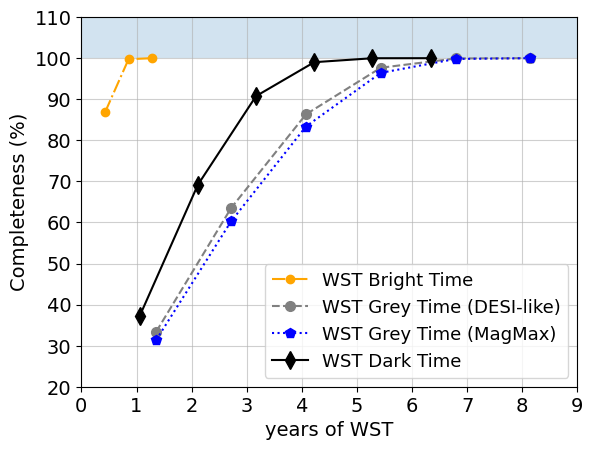

In [6]:

import matplotlib.pyplot as plt

for i, config in enumerate([config_bright_update, config_grey_update,  config_grey_magmax_update,  config_dark_update]):
   # if i > 0: break
    config_time =[]
    time = 0
    n_pointings = 0

    S_survey             = config['S_survey']
    N_fibres             = config['N_fibres']
    S_FoV                = config['S_FoV']
    t_exp                = config['exposure_time']
    observational_fraction = config['observation_fraction']
    t_full_sky_one_exp   = t_exp * (S_survey / S_FoV)
    n_fibres             = N_fibres / S_FoV
    for j, tracer in enumerate(config['tracers']):
        index = np.argmin(abs(config[tracer + '_' + 'mag_centers'] - mag_max[i][j]))
        time += config[tracer + '_' + 'calendar_time'][index]
        n_pointings += config[tracer + '_' + 'target_pointings'][index]

    nf = 30000/3
    pmax = int(n_pointings / nf)+1
    comp, passes = _survey_design_telescope_metrics.completeness_vs_pass(n_pointings, n_fibres)
    print(passes)
    total_time = t_full_sky_one_exp * np.array(passes)/ (observational_fraction * 365.25 * 24 * 3600)
    plt.plot(total_time, 100*np.array(comp), color=color[i],  ls = ls[i], marker=marker[i],label = config['survey_type'], markersize=markersize[i])
    #plt.vlines(passes, ymin=0, ymax=total_time, color=color[i], linestyles=ls[i],)

plt.ylabel('Completeness (%)', fontsize=14)
plt.xlabel('years of WST', fontsize=14)

#plt.plot([], [],label = config['survey_type'],  ls = ls[i],color=color[i], marker=marker[i], markersize=19)
plt.ylim(20, 110)
plt.xlim(0, 9)
plt.grid(which='major')
#plt.text(0.1, 62, '5 years', color='C0')

#plt.ylim(2, 40)
plt.legend(ncols=1, fontsize=13)
plt.tick_params(axis='both', labelsize=14)

plt.fill_between(np.linspace(-10, 10, 100), 100+0*np.linspace(-10, 10, 100), 200+0*np.linspace(-10, 10, 100), alpha=0.2)
#plt.xlim(0.5, 6.5)
#plt.ylim(0.1, 1.5)
plt.ylim(20, 110)
plt.xlim(0, 9)
plt.ylim(20, 110)

plt.xticks(np.arange(0, 10, 1))
plt.yticks(np.arange(20, 111, 10))

plt.grid(True, which='major', axis='both', linestyle='-', alpha=0.6)
plt.savefig('../figures_for_paper/survey_calendar_time.png', dpi = 300, bbox_inches='tight',)